# Proyecto: Detección Automática de Noticias Falsas
##Análisis Comparativo entre Machine Learning Clásico y Deep Learning

**Máster en Ciberseguridad e Inteligencia Artificial - CEI**  
**Autora:** Paula Ruiz Gardon  
**Fecha:** Abril 2026

Este notebook implementa un sistema de clasificación de noticias como **reales o falsas** utilizando **BERT** y **Hugging Face Transformers**. Se incluyen pasos de preprocesamiento, tokenización, creación de datasets PyTorch, entrenamiento y evaluación.

## 1. Configuración del Entorno e Importación de Librerías
En esta primera fase, instalamos e importamos las librerías necesarias para el análisis de datos, procesamiento de lenguaje natural (NLP) y construcción de los modelos de Machine Learning y Deep Learning (Transformers).

In [1]:
# Instalación de librerías avanzadas
!pip install transformers datasets evaluate

# Importación de librerías básicas y análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Importación de librerías para Procesamiento de Lenguaje Natural
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

# Importación de librerías para Machine Learning Clásico (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Carga y Estructuración del Dataset
Se procede a montar la unidad de Google Drive para acceder a los archivos de datos. Trabajaremos con dos conjuntos: `Fake.csv` y `True.csv`. A cada uno se le asignará una etiqueta numérica binaria donde **1 indica noticia falsa (Fake)** y **0 indica noticia verdadera (Real)**.

In [2]:
from google.colab import drive
import re

drive.mount('/content/drive')

# Carga de los datasets desde Google Drive
df_fake = pd.read_csv('/content/drive/MyDrive/Fake.csv')
df_true = pd.read_csv('/content/drive/MyDrive/True.csv')

# Creación de la variable objetivo (Target)
df_fake['label'] = 1   # Clase 1: Fake
df_true['label'] = 0   # Clase 0: Real

# Fusión de ambos datasets en un único DataFrame
df = pd.concat([df_fake, df_true], ignore_index=True)

# Mezclar (shuffle) el dataset para que las clases no estén ordenadas
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Eliminar fuga de datos de la columna 'text'
def eliminar_fuga_datos(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'^.*?\(Reuters\)\s*-\s*', '', text, flags=re.IGNORECASE)
    if ' - ' in text[:60]:
        text = text.split(' - ', 1)[1]
    return text

print("Eliminando fuga de datos (Data Leakage)...")
df['text'] = df['text'].apply(eliminar_fuga_datos)

# Combinar título y texto en una sola columna para tener más contexto
df['content'] = df['title'] + " " + df['text']

# Mostrar las dimensiones y las primeras filas
print(f"Dimensiones del dataset combinado: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Eliminando fuga de datos (Data Leakage)...
Dimensiones del dataset combinado: (44898, 6)


,title,text,subject,date,label,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,U.S. President Donald Trump removed his chief ...,politicsNews,"April 5, 2017",0,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico Governor Ricardo Rossello said on ...,politicsNews,"September 27, 2017",0,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,Most U.S. presidential candidates go abroad to...,politicsNews,"June 24, 2016",0,Donald Trump heads for Scotland to reopen a go...


## 3. Análisis Exploratorio de los Datos (EDA)
Antes de procesar el texto, analizamos la distribución de las clases para comprobar si el dataset está balanceado y verificamos si existen valores nulos que deban ser tratados.

Valores nulos en el dataset:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64


/tmp/ipykernel_16844/1144275218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')
/tmp/ipykernel_16844/1144275218.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Reales (0)', 'Falsas (1)'])


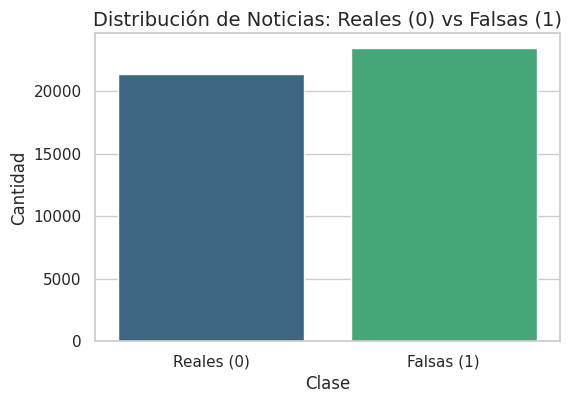

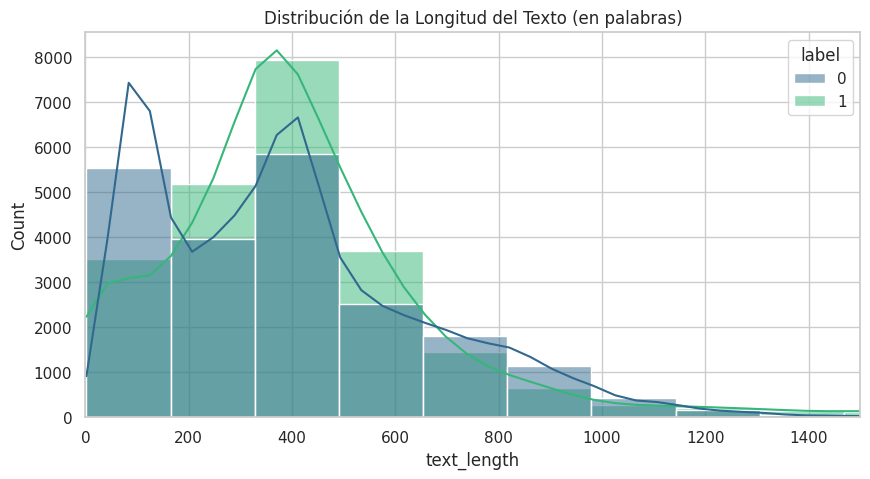

In [3]:
# 1. Comprobación de valores nulos
print("Valores nulos en el dataset:")
print(df.isnull().sum())

# 2. Distribución de las clases
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribución de Noticias: Reales (0) vs Falsas (1)', fontsize=14)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
ax.set_xticklabels(['Reales (0)', 'Falsas (1)'])
plt.show()

# 3. Análisis de la longitud del texto
df['text_length'] = df['content'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.histplot(df, x='text_length', hue='label', bins=50, kde=True, palette='viridis')
plt.title('Distribución de la Longitud del Texto (en palabras)')
plt.xlim(0, 1500) # Limitamos a 1500 para evitar que outliers aplasten la gráfica
plt.show()

## 4. Preprocesamiento de Datos Textuales
El texto en bruto contiene ruido (URLs, signos de puntuación, caracteres especiales) que no aporta valor semántico a los modelos.
En esta fase creamos una función para limpiar el texto, pasarlo a minúsculas, eliminar _stopwords_ (palabras vacías) y aplicar lematización.

In [4]:
# Definición de las stopwords en inglés (idioma principal del dataset Kaggle)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# 1. Limpieza estricta para ML Clásico (TF-IDF)
def clean_text_ml(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

# 2. Limpieza ligera para Deep Learning (BERT)
def clean_text_bert(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicar las limpiezas
print("Iniciando preprocesamiento textual...")
df['clean_content_ml'] = df['content'].apply(clean_text_ml)
df['clean_content_bert'] = df['content'].apply(clean_text_bert)
print("Limpieza completada.")

# Visualizar el cambio
df[['content', 'clean_content_ml', 'clean_content_bert']].head(3)

Iniciando preprocesamiento textual...
Limpieza completada.


,content,clean_content_ml,clean_content_bert
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...,Puerto Rico expects U.S. to lift Jones Act shi...


## 5. División de los Datos
Para evaluar correctamente la capacidad de generalización de nuestros modelos, dividiremos el dataset en tres subconjuntos: Entrenamiento (70%), Validación (15%) y Prueba (15%).

In [5]:
# Dividimos el DataFrame completo en lugar de variables aisladas
# Primera división: Separar Train (70%) y el resto (30%)
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])

# Segunda división: Separar el 30% restante en Validación (15%) y Test (15%)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['label'])

print(f"Tamaño de Entrenamiento: {df_train.shape[0]}")
print(f"Tamaño de Validación: {df_val.shape[0]}")
print(f"Tamaño de Prueba (Test): {df_test.shape[0]}")

Tamaño de Entrenamiento: 31428
Tamaño de Validación: 6735
Tamaño de Prueba (Test): 6735


## 6. Modelo 1: Machine Learning Clásico (TF-IDF + Random Forest / Logistic Regression)
Se vectoriza el texto limpio utilizando la técnica **TF-IDF (Term Frequency - Inverse Document Frequency)**, la cual pondera la importancia de cada palabra. Posteriormente, entrenamos un modelo clásico (en este caso Regresión Logística, por su alta eficiencia y excelente desempeño como línea base en NLP).

In [6]:
# 1. Inicializar el vectorizador TF-IDF (limitado a las 5000 palabras más importantes)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# 2. Vectorizar los conjuntos de datos usando la columna ESPECÍFICA para ML
print("Vectorizando textos con TF-IDF...")
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['clean_content_ml'])
X_val_tfidf = tfidf_vectorizer.transform(df_val['clean_content_ml'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['clean_content_ml'])

# 3. Inicializar y entrenar el modelo (Regresión Logística como base sólida)
ml_model = LogisticRegression(max_iter=1000, random_state=42)
print("Entrenando modelo clásico...")
ml_model.fit(X_train_tfidf, df_train['label'])

# 4. Predicciones en el conjunto de prueba
y_pred_ml = ml_model.predict(X_test_tfidf)
print("Entrenamiento completado.")

Vectorizando textos con TF-IDF...
Entrenando modelo clásico...
Entrenamiento completado.


## 7. Evaluación del Modelo Clásico
Se evalúa el rendimiento del modelo utilizando las métricas definidas en la memoria (Accuracy, Precision, Recall y F1-Score) y se genera la Matriz de Confusión.

--- REPORTE DE CLASIFICACIÓN (MODELO CLÁSICO) ---
              precision    recall  f1-score   support

    Real (0)       0.98      0.99      0.98      3212
    Fake (1)       0.99      0.98      0.99      3523

    accuracy                           0.98      6735
   macro avg       0.98      0.98      0.98      6735
weighted avg       0.98      0.98      0.98      6735



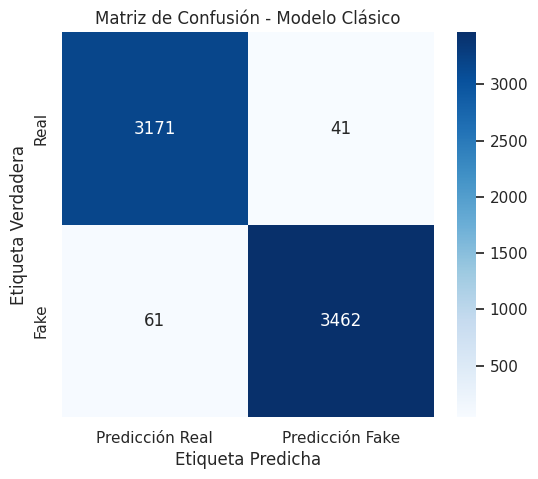

In [8]:
# Reporte de clasificación
print("--- REPORTE DE CLASIFICACIÓN (MODELO CLÁSICO) ---")
print(classification_report(df_test['label'], y_pred_ml, target_names=['Real (0)', 'Fake (1)']))

# Matriz de Confusión Visual
cm_ml = confusion_matrix(df_test['label'], y_pred_ml)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicción Real', 'Predicción Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Matriz de Confusión - Modelo Clásico')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

## 8. Modelo 2: Deep Learning (Transformador preentrenado - BERT)
Para este enfoque avanzado, utilizamos la librería `transformers` de Hugging Face. Importaremos un modelo preentrenado (`distilbert-base-uncased`, por ser más liviano y rápido) y lo adaptaremos a nuestra tarea de clasificación binaria.
*(Nota: Este entrenamiento requiere entorno con GPU activada en Colab).*

In [9]:
# Para no sobrecargar la RAM, demostramos el código de fine-tuning con una submuestra.
# Si  GPU completa, eliminamos los recortes [:2000] y [:500].

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import pandas as pd

# 1. Cargar Tokenizador y Modelo (DistilBERT: clasificación binaria)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Convertir los datos a formato Dataset de HuggingFace (USANDO LA COLUMNA DE BERT)
train_dataset = Dataset.from_pandas(pd.DataFrame({
    'text': df_train['clean_content_bert'][:2000].values,
    'label': df_train['label'][:2000].values
}))

test_dataset = Dataset.from_pandas(pd.DataFrame({
    'text': df_test['clean_content_bert'][:500].values,
    'label': df_test['label'][:500].values
}))

# 3. Función de tokenización
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=256)

# Aplicar tokenización
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 4. Configurar hiperparámetros de entrenamiento (CORREGIDO: eval_strategy)
training_args = TrainingArguments(
    output_dir="./resultados_bert",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

# 5. Definir el Trainer
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

# 6. Iniciar el entrenamiento
print("Iniciando entrenamiento del modelo Transformer...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Iniciando entrenamiento del modelo Transformer...


Epoch,Training Loss,Validation Loss
1,No log,0.060676
2,No log,0.073373
3,No log,0.041773


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=0.08352425638834636, metrics={'train_runtime': 151.6741, 'train_samples_per_second': 39.558, 'train_steps_per_second': 2.472, 'total_flos': 397402195968000.0, 'train_loss': 0.08352425638834636, 'epoch': 3.0})

## 9. Evaluación del Modelo de Deep Learning (BERT)
Una vez finalizado el proceso de *fine-tuning*, procedemos a evaluar el rendimiento del modelo sobre el conjunto de prueba (Test).
Dado que los modelos basados en Transformers devuelven *logits* (valores brutos de predicción antes de aplicar la función de activación), debemos extraer la clase con mayor probabilidad mediante `np.argmax`. Posteriormente, calcularemos las métricas y la matriz de confusión para compararlas con el modelo clásico.

Generando predicciones con el modelo BERT...



--- REPORTE DE CLASIFICACIÓN (MODELO BERT) ---
              precision    recall  f1-score   support

    Real (0)       0.98      1.00      0.99       245
    Fake (1)       1.00      0.98      0.99       255

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



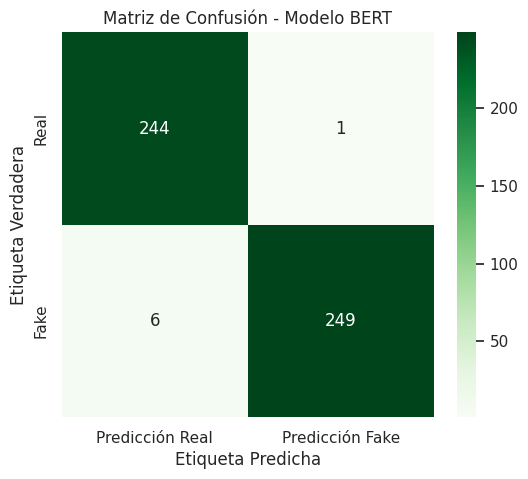

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando predicciones con el modelo BERT...")

# 1. Obtener las predicciones en bruto (logits) sobre el conjunto de test
raw_predictions = trainer.predict(tokenized_test)

# 2. Extraer los logits y las etiquetas reales
logits = raw_predictions.predictions
y_true_bert = raw_predictions.label_ids

# 3. Convertir los logits a etiquetas de clase (0 o 1) escogiendo el valor máximo
y_pred_bert = np.argmax(logits, axis=-1)

# 4. Reporte de clasificación (Accuracy, Precision, Recall, F1-Score)
print("\n--- REPORTE DE CLASIFICACIÓN (MODELO BERT) ---")
print(classification_report(y_true_bert, y_pred_bert, target_names=['Real (0)', 'Fake (1)']))

# 5. Generar y visualizar la Matriz de Confusión
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicción Real', 'Predicción Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Matriz de Confusión - Modelo BERT')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

## 10. Comparación de Resultados (Machine Learning vs Deep Learning)
En esta sección recopilamos las métricas principales obtenidas por ambos modelos y las visualizamos en un gráfico de barras. Esto nos permite concluir de forma clara y objetiva qué enfoque ha proporcionado un mejor rendimiento para la tarea de detección de noticias falsas.

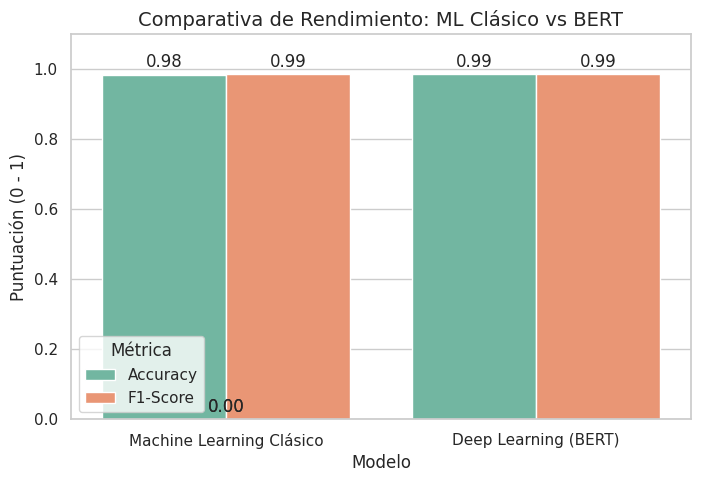

In [11]:
# 1. Extraer las métricas de ambos modelos
acc_ml = accuracy_score(df_test['label'], y_pred_ml)
f1_ml = f1_score(df_test['label'], y_pred_ml)

acc_bert = accuracy_score(y_true_bert, y_pred_bert)
f1_bert = f1_score(y_true_bert, y_pred_bert)

# 2. Crear un DataFrame para la gráfica
data_metrics = {
    'Modelo': ['Machine Learning Clásico', 'Machine Learning Clásico', 'Deep Learning (BERT)', 'Deep Learning (BERT)'],
    'Métrica': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Puntuación': [acc_ml, f1_ml, acc_bert, f1_bert]
}
df_metrics = pd.DataFrame(data_metrics)

# 3. Visualizar la comparativa
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Modelo', y='Puntuación', hue='Métrica', data=df_metrics, palette='Set2')
plt.title('Comparativa de Rendimiento: ML Clásico vs BERT', fontsize=14)
plt.ylim(0, 1.1)
plt.ylabel('Puntuación (0 - 1)')

# Añadir los valores numéricos sobre las barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

## 11. Prueba Interactiva del Modelo (Inferencia)
Para demostrar la utilidad real del sistema desarrollado, creamos una función que recibe un texto cualquiera (una noticia copiada de internet o inventada) y utiliza nuestro modelo BERT entrenado para predecir si es una noticia Real o Falsa.

In [13]:
import torch

def predecir_noticia(texto_noticia):
    """
    Función que recibe un texto, lo tokeniza y utiliza el modelo BERT
    entrenado para predecir su veracidad.
    """
    # 1. Poner el modelo en modo evaluación
    model_bert.eval()

    # 2. Tokenizar el texto de entrada
    inputs = tokenizer(texto_noticia, padding="max_length", truncation=True, max_length=256, return_tensors="pt")

    # Mover los tensores al mismo dispositivo que el modelo
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model_bert.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Obtener la predicción
    with torch.no_grad():
        outputs = model_bert(**inputs)
        logits = outputs.logits
        prediccion = torch.argmax(logits, dim=-1).item()

    # 4. Mostrar el resultado
    if prediccion == 1:
        print("\nPREDICCIÓN: NOTICIA FALSA (FAKE NEWS)")
    else:
        print("\nPREDICCIÓN: NOTICIA REAL (TRUE)")

    print(f"Texto analizado: '{texto_noticia[:150]}...'")

# --- PRUEBAS ---
# Prueba 1: Texto inventado claramente sensacionalista (Fake)
texto_prueba_1 = "BREAKING: Aliens have landed in New York and the government is hiding it! President confirms UFOs are real and they are controlling our minds through 5G towers."
predecir_noticia(texto_prueba_1)

# Prueba 2: Texto formal similar a una noticia real
texto_prueba_2 = "The central bank announced today a new set of economic measures to combat inflation. Interest rates will be raised by 0.5% starting next month, according to the official statement released by the Ministry of Economy."
predecir_noticia(texto_prueba_2)


PREDICCIÓN: NOTICIA FALSA (FAKE NEWS)
Texto analizado: 'BREAKING: Aliens have landed in New York and the government is hiding it! President confirms UFOs are real and they are controlling our minds through ...'

PREDICCIÓN: NOTICIA REAL (TRUE)
Texto analizado: 'The central bank announced today a new set of economic measures to combat inflation. Interest rates will be raised by 0.5% starting next month, accord...'


## 12. Guardado del Modelo y el Tokenizador
Una vez estamos satisfechos con los resultados de nuestro modelo de Deep Learning, guardamos los pesos y el tokenizador en Google Drive. De esta forma, podremos cargar el modelo en el futuro para desplegarlo en una aplicación web o probarlo sin necesidad de volver a entrenar.

In [14]:
# Ruta donde queremos guardar el modelo dentro de nuestro Google Drive
ruta_guardado = "/content/drive/MyDrive/Modelo_FakeNews_BERT"

# Guardar el modelo entrenado
model_bert.save_pretrained(ruta_guardado)

# Guardar el tokenizador
tokenizer.save_pretrained(ruta_guardado)

print(f"¡Modelo y tokenizador guardados exitosamente en: {ruta_guardado}!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

¡Modelo y tokenizador guardados exitosamente en: /content/drive/MyDrive/Modelo_FakeNews_BERT!
